In [1]:
# Activer l'affichage des graphiques directement dans le notebook
%matplotlib inline
# Supprimer les messages d'avertissement pour un affichage plus propre
import warnings; warnings.filterwarnings("ignore")

# Importer les bibliothèques essentielles pour la Data science
import pandas as pd, numpy as np, matplotlib.pyplot as plt
# Importer Path pour les opérations sur le système de fichiers
from pathlib import Path

In [2]:
# 1→4) CHARGEMENT + FEATURES + SPLIT
H = 10                     # horizon de prédiction (min)
TARGET = "Aggregate"       # cible

# 1) charger le fichier propre produit dans 01
# Chargement du fichier de données nettoyé avec la colonne Time comme index datetime
df = pd.read_csv("data/processed/House_21_1min_clean.csv",
                 parse_dates=["Time"], index_col="Time").sort_index()

# 2) feature engineering (sans fuite temporelle)
X = df.copy()

# Création de caractéristiques temporelles à partir de l'index datetime
X["hour"]       = X.index.hour                    # Heure du jour (0-23)
X["dow"]        = X.index.dayofweek               # Jour de la semaine (0-6, Lundi=0)
X["month"]      = X.index.month                   # Mois (1-12)
X["is_weekend"] = (X["dow"] >= 5).astype(int)     # Indicateur binaire pour les jours de weekend
# Encodage cyclique de l'heure et du jour de la semaine avec transformations sinus et cosinus
X["hour_sin"]   = np.sin(2*np.pi*X["hour"]/24);  X["hour_cos"] = np.cos(2*np.pi*X["hour"]/24)
X["dow_sin"]    = np.sin(2*np.pi*X["dow"]/7);    X["dow_cos"]  = np.cos(2*np.pi*X["dow"]/7)

# Création de variables décalées (lags) de la cible (60 minutes précédentes)
for k in range(1, 61):   # 1..60 minutes
    X[f"agg_lag_{k}"] = X[TARGET].shift(k)

# Création de statistiques sur fenêtres glissantes (moyenne et écart-type) des valeurs passées
X["agg_rollmean_5"]  = X[TARGET].shift(1).rolling(5,  min_periods=3).mean()   # Moyenne glissante sur 5 min
X["agg_rollstd_5"]   = X[TARGET].shift(1).rolling(5,  min_periods=3).std()    # Écart-type glissant sur 5 min
X["agg_rollmean_15"] = X[TARGET].shift(1).rolling(15, min_periods=5).mean()   # Moyenne glissante sur 15 min
X["agg_rollmean_60"] = X[TARGET].shift(1).rolling(60, min_periods=10).mean()  # Moyenne glissante sur 60 min

# Création de la variable cible : la valeur de TARGET H minutes dans le futur
X["target"] = X[TARGET].shift(-H)

# Définition des colonnes de caractéristiques à utiliser
appliance_cols = [c for c in df.columns if c.lower().startswith("appliance")]  # Colonnes des appareils
feat_cols = (["hour","dow","month","is_weekend","hour_sin","hour_cos","dow_sin","dow_cos"]
             + [f"agg_lag_{k}" for k in range(1,61)]
             + ["agg_rollmean_5","agg_rollstd_5","agg_rollmean_15","agg_rollmean_60"]
             + appliance_cols)

# Création du jeu de données final en supprimant les lignes avec valeurs manquantes
XY = X[feat_cols + ["target"]].dropna()
# Extraction des caractéristiques (X_all) et de la variable cible (y_all) à partir du jeu de données nettoyé XY
# X_all contient toutes les colonnes de caractéristiques définies dans feat_cols
# y_all contient les valeurs cibles (consommation d'énergie future)
X_all, y_all = XY[feat_cols], XY["target"]

# 4) split chronologique 80/20
# Division des données en ensembles d'entraînement (80%) et de test (20%) de manière chronologique
split = int(len(X_all)*0.8)
X_train, X_test = X_all.iloc[:split],  X_all.iloc[split:]
y_train, y_test = y_all.iloc[:split],  y_all.iloc[split:]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (564213, 81) | Test: (141054, 81)


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def rmse(y_true, y_pred):
    """
    Calcule l'erreur quadratique moyenne (RMSE) entre les valeurs réelles et prédites.
    
    Paramètres:
    -----------
    y_true : array-like
        Valeurs cibles réelles
    y_pred : array-like
        Valeurs cibles prédites
        
    Retourne:
    ---------
    float
        Valeur de l'erreur quadratique moyenne
    """
    # compatible avec toutes versions sklearn
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    """
    Calcule l'erreur absolue moyenne en pourcentage (MAPE) entre les valeurs réelles et prédites.
    
    Paramètres:
    -----------
    y_true : array-like
        Valeurs cibles réelles
    y_pred : array-like
        Valeurs cibles prédites
        
    Retourne:
    ---------
    float
        Valeur de l'erreur absolue moyenne en pourcentage
    """
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    # Ajout d'une petite valeur (1e-9) pour éviter la division par zéro
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100

def evaluate(y_true, y_pred):
    """
    Évalue la performance du modèle à l'aide de plusieurs métriques.
    
    Paramètres:
    -----------
    y_true : array-like
        Valeurs cibles réelles
    y_pred : array-like
        Valeurs cibles prédites
        
    Retourne:
    ---------
    dict
        Dictionnaire contenant les métriques MAE, RMSE, MAPE et R²
    """
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "MAPE%": mape(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

def plot_pred_vs_true(y_true, y_pred, title="Vrai vs prédit"):
    """
    Trace les valeurs réelles par rapport aux valeurs prédites pour une comparaison visuelle.
    
    Paramètres:
    -----------
    y_true : pandas.Series
        Valeurs cibles réelles avec index
    y_pred : array-like
        Valeurs cibles prédites
    title : str, default="Vrai vs prédit"
        Titre du graphique
        
    Retourne:
    ---------
    None
        Affiche le graphique
    """
    plt.figure(figsize=(12,4))
    idx = y_true.index[:3000]   # zoom pour lisibilité
    plt.plot(idx, y_true.loc[idx].values, label="Vrai")
    plt.plot(idx, pd.Series(y_pred, index=y_true.index).loc[idx].values, label="Prédit")
    plt.title(title); plt.ylabel("W"); plt.legend(); plt.show()

Baseline: {'MAE': 121.05494510058118, 'RMSE': 364.786087858888, 'MAPE%': 23.187038211578013, 'R2': 0.7746843299818652}


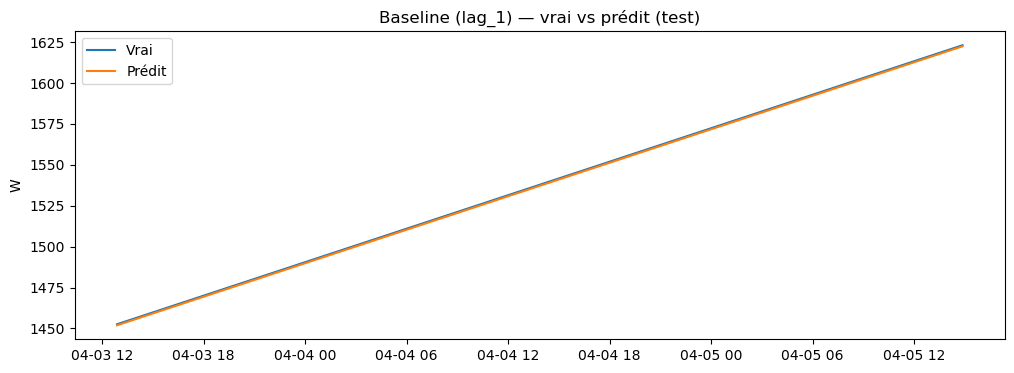

In [4]:
# Utiliser le décalage de 1 jour comme modèle de prédiction de référence (prédiction de demain = valeur d'aujourd'hui)
baseline = X.loc[X_test.index, "agg_lag_1"]      # Utiliser la valeur d'hier comme prédiction pour aujourd'hui
assert baseline.index.equals(y_test.index)       # Vérifier que les indices correspondent entre la prédiction et les données de test
base_metrics = evaluate(y_test, baseline)        # Calculer les métriques de performance pour le modèle de référence
print("Baseline:", base_metrics)                 # Afficher les métriques de performance du modèle de référence
plot_pred_vs_true(y_test, baseline, "Baseline (lag_1) — vrai vs prédit (test)")  # Visualiser les prédictions de référence vs les valeurs réelles

In [5]:
X_train_use, X_test_use = X_train, X_test    # alias par défaut

In [6]:
# Définir les caractéristiques à conserver dans le jeu de données
keep = ["hour","dow","month","is_weekend","hour_sin","hour_cos","dow_sin","dow_cos"]  # Caractéristiques temporelles
keep += [f"agg_lag_{k}" for k in range(1,31)]   # Ajouter les caractéristiques de décalage de 1 à 30 pas de temps
keep += ["agg_rollmean_5","agg_rollstd_5","agg_rollmean_15","agg_rollmean_60"]  # Caractéristiques de statistiques glissantes
keep += [c for c in X_train.columns if c.lower().startswith("appliance")]  # Toutes les caractéristiques liées aux appareils

# Créer des jeux de données plus petits avec uniquement les caractéristiques sélectionnées
X_train_small = X_train[keep].copy()
X_test_small  = X_test[keep].copy()

# Renommer les variables pour plus de clarté dans le code suivant
X_train_use, X_test_use = X_train_small, X_test_small
X_train_use.shape, X_test_use.shape  # Afficher les dimensions des jeux de données réduits

((564213, 51), (141054, 51))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   39.9s
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:  3.9min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


CPU times: total: 41min 1s
Wall time: 3min 53s


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 150 out of 150 | elapsed:    0.8s finished


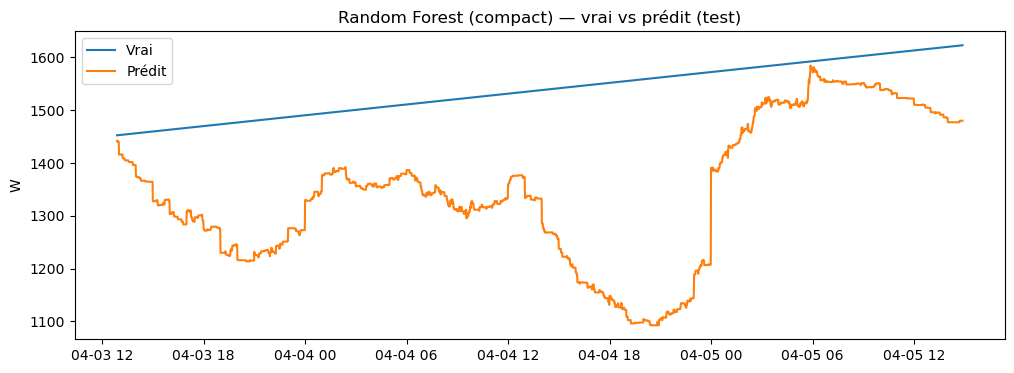

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Initialisation du modèle Random Forest Regressor avec des hyperparamètres optimisés
rf = RandomForestRegressor(
    n_estimators=150,      # Nombre d'arbres dans la forêt
    max_depth=22,          # Profondeur maximale de chaque arbre
    min_samples_split=5,   # Nombre minimum d'échantillons requis pour diviser un nœud
    min_samples_leaf=5,    # Nombre minimum d'échantillons requis dans une feuille
    max_features="sqrt",   # Nombre de caractéristiques à considérer (racine carrée du total)
    max_samples=0.5,       # Utilise 50% des échantillons par arbre - réduit le surapprentissage
    n_jobs=-1,             # Utilise tous les processeurs disponibles
    random_state=42,       # Fixe la graine pour la reproductibilité
    verbose=1              # Affiche la progression de l'entraînement
)
%time rf.fit(X_train_use, y_train)  # Entraîne le modèle et mesure le temps d'exécution

# Effectue des prédictions sur l'ensemble de test
y_pred_rf = pd.Series(rf.predict(X_test_use), index=y_test.index)
# Calcule et affiche les métriques d'évaluation
rf_metrics = evaluate(y_test, y_pred_rf); rf_metrics
# Visualise les valeurs prédites vs les valeurs réelles
plot_pred_vs_true(y_test, y_pred_rf, "Random Forest (compact) — vrai vs prédit (test)")

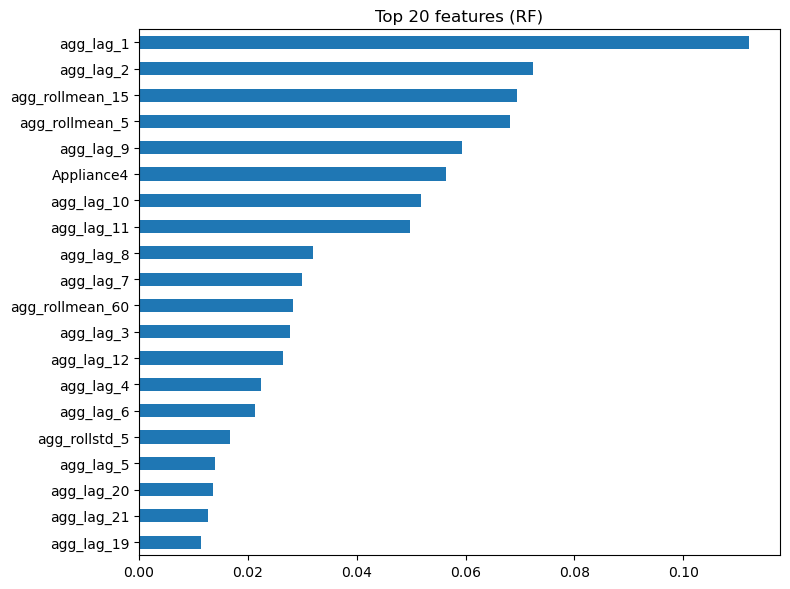

agg_lag_1          0.112161
agg_lag_2          0.072359
agg_rollmean_15    0.069383
agg_rollmean_5     0.068146
agg_lag_9          0.059269
Appliance4         0.056436
agg_lag_10         0.051773
agg_lag_11         0.049801
agg_lag_8          0.031890
agg_lag_7          0.029936
dtype: float64

In [8]:
# Calcule l'importance des caractéristiques à partir du modèle Random Forest et les trie par ordre décroissant, en gardant les 20 premières
imp = pd.Series(rf.feature_importances_, index=X_train_use.columns).sort_values(ascending=False).head(20)

# Crée un graphique à barres horizontales des importances des caractéristiques
plt.figure(figsize=(8,6))  # Définit la taille de la figure
imp.sort_values().plot(kind="barh")  # Trace des barres horizontales, triées par importance
plt.title("Top 20 features (RF)")  # Ajoute un titre
plt.tight_layout()  # Ajuste la mise en page pour éviter le rognage des étiquettes
plt.show()  # Affiche le graphique

# Affiche les 10 caractéristiques les plus importantes sous forme de Series pandas
imp.head(10)

In [9]:
# Accéder au dictionnaire des métriques pour le modèle Random Forest
# Celui-ci contient des métriques d'évaluation comme la précision, le rappel, etc.
rf_metrics

{'MAE': 198.70130547035828,
 'RMSE': 302.51155582410075,
 'MAPE%': 29.64558479381022,
 'R2': 0.8450474237863911}

In [10]:
# Installer la bibliothèque XGBoost silencieusement (avec l'option -q pour supprimer les sorties)
!pip install xgboost -q

In [11]:
# Importer la classe XGBRegressor de la bibliothèque xgboost
# XGBRegressor est une implémentation des arbres de décision boostés par gradient
# conçue pour les tâches de régression avec haute performance et efficacité
from xgboost import XGBRegressor

CPU times: total: 11min 49s
Wall time: 1min 29s


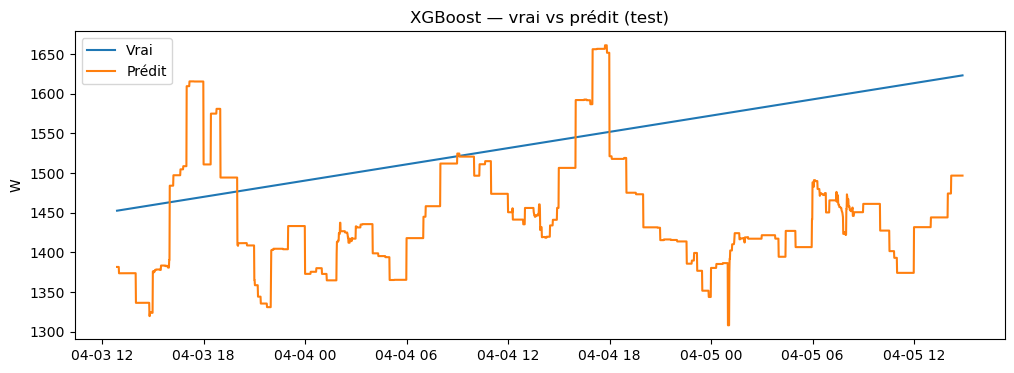

In [12]:
try:
    # Importer le régresseur XGBoost
    from xgboost import XGBRegressor

    # Initialiser le régresseur XGBoost avec les hyperparamètres
    xgb = XGBRegressor(
        n_estimators=800,      # Nombre d'arbres/itérations de boosting
        max_depth=8,           # Profondeur maximale de chaque arbre
        learning_rate=0.05,    # Taux d'apprentissage pour éviter le surapprentissage
        subsample=0.8,         # Fraction des échantillons utilisés pour chaque arbre (réduit le surapprentissage)
        colsample_bytree=0.8,  # Fraction des caractéristiques utilisées pour chaque arbre
        reg_lambda=1.0,        # Terme de régularisation L2
        tree_method="hist",    # Utilise l'algorithme basé sur les histogrammes pour un entraînement plus rapide
        random_state=42,       # Pour la reproductibilité
        n_jobs=-1,             # Utilise tous les cœurs CPU disponibles
        eval_metric="rmse",    # Métrique d'évaluation (Erreur quadratique moyenne)
    )
    # Entraîner le modèle et chronométrer l'exécution
    %time xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Faire des prédictions sur l'ensemble de test et convertir en Series pandas avec le même index
    y_pred_xgb = pd.Series(xgb.predict(X_test), index=y_test.index)
    # Évaluer les performances du modèle et stocker les métriques
    xgb_metrics = evaluate(y_test, y_pred_xgb); xgb_metrics

    # Tracer les valeurs réelles vs prédites
    plot_pred_vs_true(y_test, y_pred_xgb, "XGBoost — vrai vs prédit (test)")
except Exception as e:
    # Gérer le cas où XGBoost n'est pas disponible
    print("XGBoost indisponible :", e)
    xgb_metrics = None

In [13]:
# Comparaison des modèles entraînés
rows = [("Baseline", base_metrics)]  # Initialisation avec le modèle de référence

# Ajouter RF et XGB s'ils existent
if 'rf_metrics' in globals():  # Vérifie si le modèle RandomForest a été entraîné
    rows.append(("RandomForest", rf_metrics))
if 'xgb_metrics' in globals():  # Vérifie si le modèle XGBoost a été entraîné
    rows.append(("XGBoost", xgb_metrics))

# Création d'un tableau comparatif des performances
compare = pd.DataFrame({name: m for name, m in rows}).T  # Transpose pour avoir les modèles en lignes
compare = compare.sort_values("RMSE")  # Tri par RMSE croissante (meilleur modèle en premier)
display(compare)  # Affichage du tableau comparatif

best_name = compare.index[0]  # Récupération du nom du meilleur modèle (première ligne après tri)
print(f"Meilleur modèle : {best_name}")  # Affichage du meilleur modèle

,MAE,RMSE,MAPE%,R2
RandomForest,198.701305,302.511556,29.645585,0.845047
Baseline,121.054945,364.786088,23.187038,0.774684
XGBoost,302.781208,422.010619,38.406187,0.698448


Meilleur modèle : RandomForest


In [14]:
import joblib, json, pathlib

# Création du dossier 'models' s'il n'existe pas déjà
pathlib.Path("models").mkdir(parents=True, exist_ok=True)

# Sélection du modèle avec les meilleures performances parmi RandomForest et XGBoost
if best_name == "RandomForest":
    best_model = rf                  # Modèle RandomForest
    best_metrics = rf_metrics        # Métriques d'évaluation du RandomForest
    y_pred_best = y_pred_rf          # Prédictions du RandomForest
elif best_name == "XGBoost":
    best_model = xgb                 # Modèle XGBoost
    best_metrics = xgb_metrics       # Métriques d'évaluation du XGBoost
    y_pred_best = y_pred_xgb         # Prédictions du XGBoost

# Sauvegarde du modèle sélectionné au format joblib
joblib.dump(best_model, f"models/{best_name}_house21.joblib")

# Sauvegarde des méta-informations du modèle au format JSON
meta = {
    "model": best_name,              # Nom du modèle sélectionné
    "target": "Aggregate",           # Variable cible
    "horizon_min": H,                # Horizon de prédiction en minutes
    "train_end": str(X_train_use.index.max()),  # Date de fin des données d'entraînement
    "features": list(X_train_use.columns),      # Liste des features utilisées
    "metrics": {k: float(v) for k, v in best_metrics.items()}  # Conversion des métriques en float pour JSON
}
json.dump(meta, open("models/model_meta_house21.json", "w"), indent=2)

# Affichage des chemins de sauvegarde
print(f"Modèle sauvegardé : models/{best_name}_house21.joblib")
print(f"Meta              : models/model_meta_house21.json")

Modèle sauvegardé : models/RandomForest_house21.joblib
Meta              : models/model_meta_house21.json


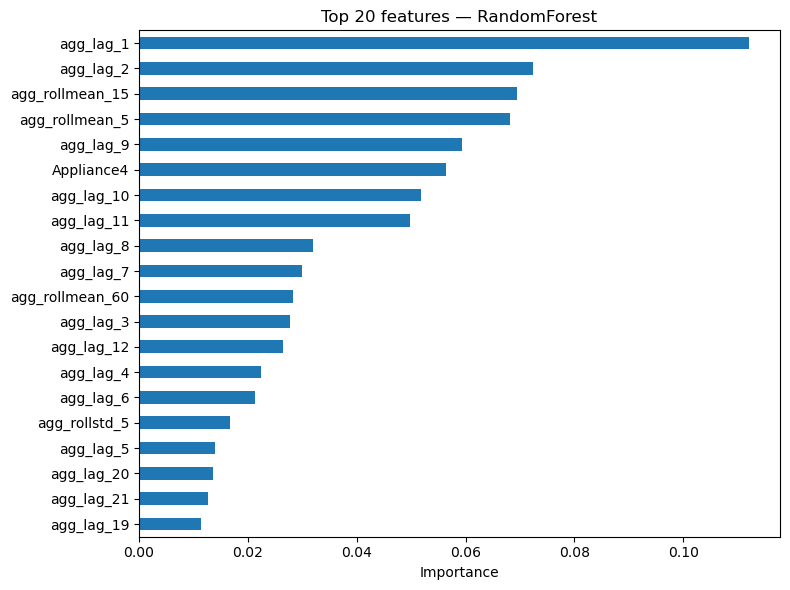

agg_lag_1          0.112161
agg_lag_2          0.072359
agg_rollmean_15    0.069383
agg_rollmean_5     0.068146
agg_lag_9          0.059269
Appliance4         0.056436
agg_lag_10         0.051773
agg_lag_11         0.049801
agg_lag_8          0.031890
agg_lag_7          0.029936
dtype: float64

In [15]:
# Importer les bibliothèques nécessaires pour la visualisation et la manipulation de données
import matplotlib.pyplot as plt
import pandas as pd

# Créer une Série des importances des caractéristiques du meilleur modèle, triée par ordre décroissant
imp = pd.Series(best_model.feature_importances_, index=X_train_use.columns).sort_values(ascending=False)

# Créer une figure avec une taille spécifiée
plt.figure(figsize=(8,6))

# Tracer les 20 meilleures caractéristiques sous forme de graphique à barres horizontales, triées par importance
imp.head(20).sort_values().plot(kind="barh")

# Ajouter un titre au graphique montrant le nom du modèle
plt.title(f"Top 20 features — {best_name}")

# Étiqueter l'axe des x
plt.xlabel("Importance")

# Ajuster la mise en page pour s'assurer que tout s'adapte correctement
plt.tight_layout()

# Afficher le graphique
plt.show()

# Retourner les 10 caractéristiques les plus importantes
imp.head(10)

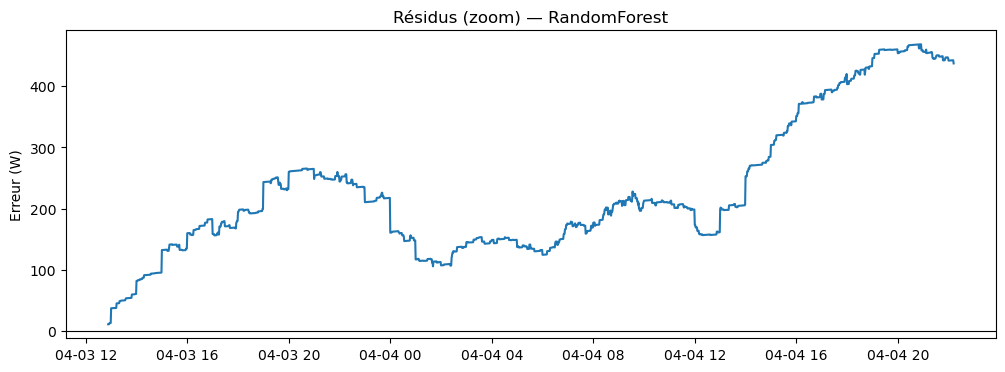

In [16]:
# Calcul des résidus (différence entre les valeurs réelles et prédites)
resid = y_test - y_pred_best

# Création d'une figure pour visualiser les résidus (seulement les 2000 premiers points pour une meilleure visibilité)
plt.figure(figsize=(12,4))
plt.plot(resid.index[:2000], resid.iloc[:2000])
plt.axhline(0, color='k', lw=0.8)  # Ajout d'une ligne horizontale à y=0 comme référence
plt.title(f"Résidus (zoom) — {best_name}")  # Titre montrant les résidus avec le nom du modèle
plt.ylabel("Erreur (W)")  # Étiquette de l'axe Y (Erreur en Watts)
plt.show()

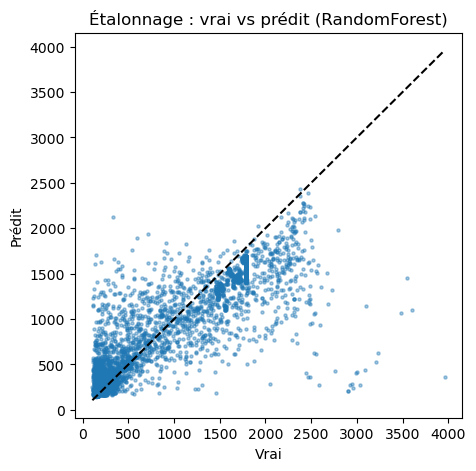

In [17]:
# On prend un échantillon aléatoire de 8000 valeurs de y_test (ou moins si test < 8000)
sample = y_test.sample(min(8000, len(y_test)), random_state=42)
# On récupère les prédictions correspondant aux mêmes index que l’échantillon
pred_s = y_pred_best.loc[sample.index]
# On crée une nouvelle figure carrée
plt.figure(figsize=(5,5))
# Nuage de points : valeurs réelles vs valeurs prédites
plt.scatter(sample, pred_s, s=5, alpha=0.4)
# On calcule les limites du graphique pour tracer la diagonale
lims = [min(sample.min(), pred_s.min()), max(sample.max(), pred_s.max())]
# Ligne diagonale idéale (prédiction parfaite)
plt.plot(lims, lims, 'k--')
# Nom des axes
plt.xlabel("Vrai")
plt.ylabel("Prédit")
# Titre du graphique
plt.title(f"Étalonnage : vrai vs prédit ({best_name})")
# Affichage
plt.show()

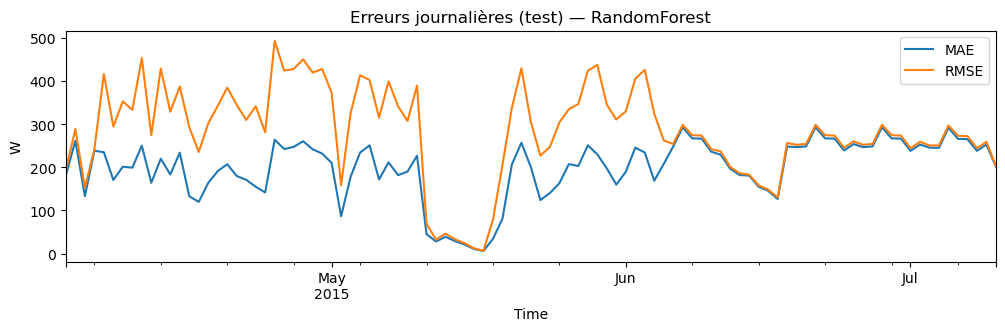

In [18]:
import numpy as np

# On regroupe y_test (valeurs vraies) et y_pred_best (prédictions) dans un même tableau
# puis on les rééchantillonne par jour ("D") et on stocke les valeurs du jour sous forme de listes
by_day = pd.concat({"true": y_test, "pred": y_pred_best}, axis=1).resample("D").apply(list)

# Fonction pour calculer le MAE entre deux listes (vrai vs prédit)
def _mae(a,b): 
    return np.mean(np.abs(np.array(a) - np.array(b)))

# Fonction pour calculer le RMSE entre deux listes (vrai vs prédit)
def _rmse(a,b): 
    return np.sqrt(np.mean((np.array(a) - np.array(b))**2))

# On crée un tableau contenant l'erreur MAE et RMSE pour chaque jour
daily = pd.DataFrame({
    "MAE":  [ _mae(t, p)  for t, p in zip(by_day["true"], by_day["pred"]) ],
    "RMSE": [ _rmse(t, p) for t, p in zip(by_day["true"], by_day["pred"]) ],
}, index=by_day.index)

# On trace les erreurs journalières MAE et RMSE sur toute la période de test
daily[["MAE","RMSE"]].plot(figsize=(12,3), title=f"Erreurs journalières (test) — {best_name}")

# Label de l’axe Y
plt.ylabel("W")

# Affichage du graphique
plt.show()

In [19]:
from pathlib import Path

# Crée le dossier "reports" s'il n'existe pas déjà
Path("reports").mkdir(exist_ok=True)

# Exporte le tableau comparatif des modèles dans un fichier CSV
compare.to_csv("reports/model_compare_house21.csv", float_format="%.4f")

# Calcule le gain en RMSE du meilleur modèle par rapport à la baseline
gain = 100 * (base_metrics["RMSE"] - best_metrics["RMSE"]) / base_metrics["RMSE"]

# Affiche un résumé final clair de la phase d'évaluation
print("=== RAPPORT FINAL — PHASE ÉVALUATION (CRISP-DM) ===")
print(f"Horizon : {H} minutes")                                 # horizon de prédiction
print(f"Baseline RMSE : {base_metrics['RMSE']:.1f} W")         # performance du modèle naïf
print(f"{best_name} RMSE : {best_metrics['RMSE']:.1f} W")      # performance du meilleur modèle
print(f"Gain vs baseline : {gain:.1f}%")                       # amélioration en pourcentage
print(f"R² : {best_metrics['R2']:.3f}")                        # variance expliquée
print(f"MAE : {best_metrics['MAE']:.1f} W")                    # erreur absolue moyenne
print(f"MAPE : {best_metrics['MAPE%']:.1f}%")                  # erreur moyenne en pourcentage

# Liste les fichiers générés pour la prochaine phase (déploiement / rapport)
print("\n Fichiers générés :")
print("• models/", best_name, "_house21.joblib")               # modèle final sauvegardé
print("• models/model_meta_house21.json")                      # métadonnées du modèle
print("• reports/model_compare_house21.csv")                   # comparaison des modèles

=== RAPPORT FINAL — PHASE ÉVALUATION (CRISP-DM) ===
Horizon : 10 minutes
Baseline RMSE : 364.8 W
RandomForest RMSE : 302.5 W
Gain vs baseline : 17.1%
R² : 0.845
MAE : 198.7 W
MAPE : 29.6%

 Fichiers générés :
• models/ RandomForest _house21.joblib
• models/model_meta_house21.json
• reports/model_compare_house21.csv
